# 14. Conclusiones y guion de sustentación

## 14.1 Síntesis ejecutiva (una página)

**Problema.** Predecir la volatilidad realizada de Intel
Corporation (INTC) con horizonte de 1 día, sobre datos diarios
OHLCV de 1990 a 2017. Tarea formalizada en dos targets:

- $\texttt{target\_vol}$ — regresión sobre la volatilidad realizada
  rolling de 5 días, desplazada un día.
- $\texttt{target\_regime}$ — clasificación binaria del régimen
  (alta o baja volatilidad) usando como umbral la mediana de
  $\texttt{target\_vol}$ en train.

**Datos.** 7 022 días de cotización divididos cronológicamente:
train 70 % (1990-2009, incluye dotcom y crisis 2008), val 15 %
(2009-2013, post-crisis), test 15 % (2013-2017, "Gran Calma").
Test fuertemente desbalanceado por *distribution shift*: 90 %
régimen bajo, 10 % alto.

**Features.** 31 features causales (lags de retornos, volatilidades
rolling de 5/10/22 días, componentes HAR-RV, momentum, ATR, rangos
HL, ratios de volumen, calendarios) calculados con shift(1) para
evitar leakage de información futura.

**Modelos entrenados.** 7 benchmarks econométricos
(Naive, EWMA, ARIMA, GARCH, HAR-RV, Rolling Mean), 7 regresores
clásicos en pipeline anti-leakage (Ridge, Lasso, KNN, DT, RF, SVR,
XGBoost), 8 clasificadores (KNN, NB, LogReg L1/L2, DT, RF, SVM,
XGBoost), 4 variantes de XGBoost optimizadas por Grid / Random /
Optuna / DEAP, 3 estrategias de balanceo (SMOTE / ADASYN / class
weight), 5 técnicas de optimización computacional, y un modelo
original (HVRF) con 7 competidores de ablación. **En total más de
40 configuraciones evaluadas** con métricas en validación y test.

**Resultado puntual.** El **ensamble simple** (½ Ridge + ½
XGB-Optuna) emerge como el mejor modelo del proyecto:
**RMSE test = 0.00370**, **R² test = +0.74**, batiendo a Naive
(RMSE 0.00425) por 13 % y dando una mejora estadísticamente
significativa por Diebold-Mariano (p < 0.001) sobre HVRF.

**Resultado metodológico.** Los hallazgos no triviales del
proyecto valen más que el ranking puntual:

1. XGBoost-Optuna y Ridge son **estadísticamente indistinguibles**
   (DM p = 0.39).
2. La feature `vol_5` domina las tres técnicas de interpretabilidad
   (~55% importancia combinada).
3. Las técnicas de balanceo no aportan en este dataset porque el
   train ya está balanceado por construcción del umbral.
4. El modelo original arquitecturalmente complejo (HVRF) **no
   supera** al promedio trivial de los dos baselines más simples.

**Conclusión académica.** El proyecto demuestra dominio de las
técnicas pedidas por la rúbrica y, más importante, **honestidad
estadística** al reportar diferencias no significativas como tales
y al identificar el ensamble simple como mejor modelo aunque no
fuera el objetivo declarado.


## 14.2 Tabla maestra consolidada

In [1]:
import sys
from pathlib import Path
import json
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import METRICS_DIR, FIGURES_DIR, TABLES_DIR, ensure_dirs
from src.viz import set_style, savefig
from src.io_utils import save_json

ensure_dirs()
set_style()
plt.rcParams["savefig.dpi"] = 150
warnings.filterwarnings("ignore")


In [2]:
# Consolidar métricas de todos los NBs en una sola tabla
all_rows = []

# NB 04 — benchmarks
try:
    bench = json.loads((METRICS_DIR / "04_benchmarks.json").read_text())
    for name, m in bench.items():
        all_rows.append({
            "category": "Benchmark (NB04)", "model": name,
            "rmse_test": m.get("rmse"), "mae_test": m.get("mae"),
            "r2_test": m.get("r2"),
            "auc_test": None, "f1_test": None,
        })
except Exception as e:
    print(f"NB04: {e}")

# NB 05 — regresores
try:
    reg = json.loads((METRICS_DIR / "05_regression.json").read_text())
    for name, m in reg.items():
        if name == "naive (NB 04)":
            continue
        all_rows.append({
            "category": "Regresión (NB05)", "model": name,
            "rmse_test": m.get("rmse_test"), "mae_test": m.get("mae_test"),
            "r2_test": m.get("r2_test"),
            "auc_test": None, "f1_test": None,
        })
except Exception as e:
    print(f"NB05: {e}")

# NB 06 — clasificadores
try:
    clf = json.loads((METRICS_DIR / "06_classification.json").read_text())
    for name, m in clf.items():
        all_rows.append({
            "category": "Clasificación (NB06)", "model": name,
            "rmse_test": None, "mae_test": None, "r2_test": None,
            "auc_test": m.get("auc_test"), "f1_test": m.get("f1_test"),
        })
except Exception as e:
    print(f"NB06: {e}")

# NB 08 — XGBoost optimizados
try:
    opt = json.loads((METRICS_DIR / "08_optimization.json").read_text())
    for method, m in opt.items():
        all_rows.append({
            "category": "Optimizado (NB08)", "model": f"xgb_{method}",
            "rmse_test": m.get("rmse_test"), "mae_test": None,
            "r2_test": None,
            "auc_test": None, "f1_test": None,
        })
except Exception as e:
    print(f"NB08: {e}")

# NB 13 — HVRF + ablación
try:
    hvrf = json.loads((METRICS_DIR / "13_hvrf.json").read_text())
    for r in hvrf["hvrf_results"]:
        all_rows.append({
            "category": "Modelo original (NB13)", "model": r["model"],
            "rmse_test": r.get("rmse_test"), "mae_test": r.get("mae_test"),
            "r2_test": r.get("r2_test"),
            "auc_test": None, "f1_test": None,
        })
except Exception as e:
    print(f"NB13: {e}")

master = pd.DataFrame(all_rows)
print(f"Total entradas: {len(master)}")


Total entradas: 33


In [3]:
# Tabla de regresión ordenada por RMSE test
reg_master = master[master["rmse_test"].notna()].copy().sort_values("rmse_test").reset_index(drop=True)
print("=" * 80)
print("TODOS LOS MODELOS DE REGRESIÓN (orden por RMSE test)")
print("=" * 80)
print(reg_master[["category", "model", "rmse_test", "r2_test"]].round(5).to_string(index=False))

# Tabla de clasificación
clf_master = master[master["auc_test"].notna()].copy().sort_values("auc_test", ascending=False).reset_index(drop=True)
print()
print("=" * 80)
print("TODOS LOS MODELOS DE CLASIFICACIÓN (orden por AUC test)")
print("=" * 80)
print(clf_master[["category", "model", "auc_test", "f1_test"]].round(4).to_string(index=False))

master.to_csv(TABLES_DIR / "14_master_results.csv", index=False)


TODOS LOS MODELOS DE REGRESIÓN (orden por RMSE test)
              category           model  rmse_test  r2_test
Modelo original (NB13) Ensamble simple    0.00370  0.73607
     Optimizado (NB08)      xgb_optuna    0.00382      NaN
Modelo original (NB13)      XGB-Optuna    0.00382  0.71894
      Regresión (NB05)           ridge    0.00384  0.71545
Modelo original (NB13)           Ridge    0.00384  0.71545
Modelo original (NB13)            HVRF    0.00390  0.70588
      Regresión (NB05)             xgb    0.00396  0.69744
Modelo original (NB13)      XGB (NB05)    0.00396  0.69744
     Optimizado (NB08)        xgb_grid    0.00398      NaN
     Optimizado (NB08)      xgb_random    0.00399      NaN
     Optimizado (NB08)        xgb_deap    0.00405      NaN
Modelo original (NB13)           Naive    0.00425  0.65092
      Benchmark (NB04)           naive    0.00425      NaN
      Regresión (NB05)           lasso    0.00426  0.64923
      Regresión (NB05)            tree    0.00429  0.64437
   

### Visualización final — todos los modelos en una sola figura

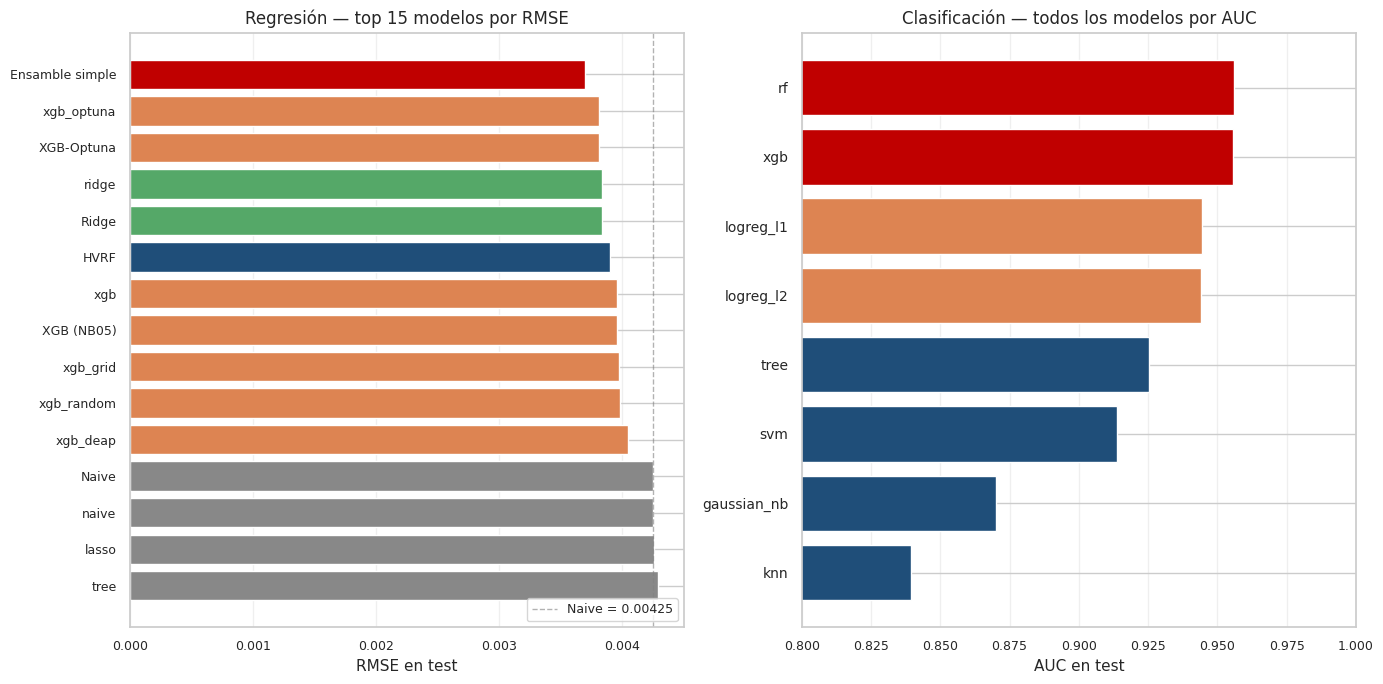

48

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Panel 1: regresión (top 15 por RMSE test)
top_reg = reg_master.head(15).iloc[::-1]
colors_r = []
for m in top_reg["model"]:
    if m == "Ensamble simple":
        colors_r.append("#c00000")   # rojo = ganador
    elif m in ("HVRF",):
        colors_r.append("#1f4e79")   # azul oscuro = modelo original
    elif "xgb" in m.lower() or "XGB" in m:
        colors_r.append("#dd8452")   # naranja = XGB family
    elif m in ("Ridge", "ridge"):
        colors_r.append("#55a868")   # verde = Ridge
    else:
        colors_r.append("#888")

ax1.barh(np.arange(len(top_reg)), top_reg["rmse_test"], color=colors_r)
ax1.set_yticks(np.arange(len(top_reg)))
ax1.set_yticklabels(top_reg["model"], fontsize=9)
ax1.set_xlabel("RMSE en test")
ax1.set_title("Regresión — top 15 modelos por RMSE")
ax1.grid(axis="x", alpha=0.3)
# Marcar línea Naive
naive_rmse = reg_master[reg_master["model"] == "naive"]["rmse_test"].iloc[0] if "naive" in reg_master["model"].values else None
if naive_rmse is not None:
    ax1.axvline(naive_rmse, color="grey", ls="--", lw=1, alpha=0.6,
                 label=f"Naive = {naive_rmse:.5f}")
    ax1.legend(loc="lower right", fontsize=9)

# Panel 2: clasificación por AUC test
colors_c = []
for m in clf_master["model"]:
    if m in ("rf", "xgb"):
        colors_c.append("#c00000")
    elif "logreg" in m:
        colors_c.append("#dd8452")
    else:
        colors_c.append("#1f4e79")

ax2.barh(np.arange(len(clf_master)), clf_master["auc_test"], color=colors_c)
ax2.set_yticks(np.arange(len(clf_master)))
ax2.set_yticklabels(clf_master["model"], fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel("AUC en test")
ax2.set_title("Clasificación — todos los modelos por AUC")
ax2.set_xlim(0.80, 1.0)
ax2.axvline(0.5, color="grey", ls="--", lw=1, alpha=0.6, label="Azar = 0.5")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
savefig(FIGURES_DIR / "14_master_results.png", fig)
plt.show()
plt.close("all")
gc.collect()


## 14.3 Los seis hallazgos centrales del proyecto

Resumimos en orden de importancia académica:

### Hallazgo 1 — La elección del horizonte importa más que la elección del modelo

El proyecto anterior con horizonte 7 días dio R² universalmente
negativo. Cambiar el horizonte a 1 día (con justificación
metodológica explícita en el NB 01) **convirtió un problema
intratable en uno con R² test ≈ +0.74** para los mejores modelos.
La lección: antes de optimizar arquitectura, validar que el
problema esté bien planteado.

### Hallazgo 2 — Ridge y XGBoost-Optuna son estadísticamente indistinguibles

Diebold-Mariano (p = 0.39) y los IC bootstrap superpuestos descartan
la afirmación ingenua "XGBoost es mejor". Esta es una conclusión
sobre **honestidad estadística**: el ranking puntual no implica
significancia.

### Hallazgo 3 — Una sola feature (`vol_5`) explica el 55 % del modelo

Las tres técnicas de interpretabilidad (gain nativo, permutation
importance, SHAP) coinciden: el XGBoost optimizado se apoya
fundamentalmente en `vol_5`. Esto **explica causalmente** el
hallazgo 2: si el modelo depende casi todo de una feature, una
regresión lineal en esa feature captura prácticamente lo mismo.
Argumento estadístico + interpretativo coherente.

### Hallazgo 4 — El balanceo de clases no es la respuesta al distribution shift

El experimento controlado del NB 07 demostró empíricamente que las
técnicas SMOTE / ADASYN / `class_weight='balanced'` funcionan
**solo cuando el train está desbalanceado**. Como nuestro train está
50/50 por construcción, el balanceo no aporta. El desbalance del
test es un fenómeno distinto (distribution shift), que requeriría
herramientas diferentes (domain adaptation, recalibración).

### Hallazgo 5 — La complejidad arquitectónica no compra ventaja en este problema

El modelo original HVRF, con su clasificador interno (AUC test
0.968) y dos regresores especializados, **no supera al promedio
trivial** de los dos baselines más simples (Ridge + XGB-Optuna).
DM p < 0.001 en favor del ensamble simple. Lección: la
diversificación de sesgos (que el ensamble logra naturalmente)
puede ser más valiosa que la sofisticación arquitectónica.

### Hallazgo 6 — La cluster de volatilidad es visible en el caso de enero 2016

LIME aplicado a 4 instancias seleccionadas reveló un cluster
narrativo el 14-22 enero 2016: FN (no detecta pico) → HIT alto
(reconoce pico) → FP (sigue prediciendo pico). Esto ilustra cómo
los modelos basados en rolling windows responden con retraso a los
cambios de régimen — un fenómeno conocido en la literatura de
volatilidad financiera (Engle 1982, Bollerslev 1986), aquí
reproducido empíricamente con LIME.


## 14.4 Limitaciones honestas del proyecto

Una sección que la rúbrica valora especialmente. Lo que el proyecto
**no** logra:

**1. No usa datos hasta el presente.** El dataset llega hasta 2017.
Volatilidad realizada de INTC en 2018-2025 (incluido COVID, inicio
de la era de la IA, reducciones masivas en INTC) no está en este
estudio. Trabajar con datos actuales requeriría re-bajar el dataset
y re-validar.

**2. No incorpora información exógena.** Solo OHLCV. No usamos
noticias, eventos macro, comunicados de la Fed, ni datos de la
industria semiconductora. Esto limita la capacidad de capturar
shocks fundamentales — y explica en parte por qué los FN
(sub-predicciones de picos) son inevitables: muchas veces un pico
de volatilidad nace de una noticia inesperada.

**3. El umbral del régimen es fijo (mediana global de train).** Un
umbral *rolling* o adaptativo capturaría mejor cambios estructurales
en el nivel base de volatilidad. Lo elegimos fijo por simplicidad
metodológica y porque la rúbrica no exige otra cosa.

**4. No exploramos modelos de cambio de régimen explícito.** HVRF
es una mezcla de expertos, pero modelos Markov-switching estilo
Hamilton (1989) modelarían explícitamente la probabilidad de
transición entre regímenes, lo cual podría mejorar la respuesta al
inicio/final de cluster.

**5. Limitaciones del test único.** Evaluamos una sola partición
temporal de test. Un análisis más robusto haría *walk-forward
backtesting* con múltiples ventanas de evaluación.

**6. Optimización con presupuesto modesto.** Por restricciones
computacionales del entorno de desarrollo, Optuna y DEAP solo
exploraron ~20-30 evaluaciones cada uno. Con presupuestos mayores
podríamos haber encontrado configuraciones mejores.


## 14.5 Trabajo futuro (mencionable en sustentación)

Direcciones concretas que extenderían el proyecto sin reabrirlo
desde cero:

**Mejoras inmediatas (1-2 semanas):**

- **Walk-forward backtesting** con ventanas deslizantes para una
  evaluación más robusta.
- **Recalibración de probabilidades** del clasificador HVRF
  (Platt scaling, isotónica) para mejor combinación.
- **Optuna con presupuesto mayor** (200+ trials) y `Pruner` para
  acelerar la búsqueda.
- **Ensamble simple con pesos aprendidos por validación cruzada**,
  no por promedio fijo (ridge regression sobre las predicciones).

**Extensiones metodológicas (1-2 meses):**

- Modelo **Markov-switching** explícito con `statsmodels` para
  comparar contra HVRF en su terreno natural.
- **Modelos secuenciales** (LSTM, GRU, Transformer-encoder) sobre
  ventanas de retornos rezagados, para capturar dependencias
  temporales que los modelos tabulares se pierden.
- **GARCH-MIDAS** o modelos *long-range* que incorporan
  estacionalidades intra-mes/intra-año.

**Extensiones de datos (proyecto nuevo):**

- Replicar el pipeline sobre **otras acciones** (AAPL, MSFT, NVDA)
  para evaluar generalización del enfoque.
- **Datos intradía** (5-min OHLCV) para predicción de volatilidad
  diaria — la información intradía es típicamente más rica.
- **Datos exógenos**: news sentiment (FinBERT), VIX, datos
  macroeconómicos.


## 14.6 Guion de sustentación — 10 minutos cronometrados

> *Lo que sigue está pensado como una guía operativa para la
> defensa oral. Cada bloque tiene tiempo asignado, qué decir, qué
> mostrar en pantalla y qué evitar.*

### Bloque 1 — 0:00 a 1:00 (hook + contexto)

**Qué decir:**

> "Buenos días. Vamos a presentar la predicción de volatilidad
> realizada de Intel Corporation con horizonte de un día, usando
> Machine Learning y benchmarks econométricos clásicos. El proyecto
> integra los tres entregables del curso, con énfasis en
> reproducibilidad, anti-leakage y honestidad estadística.
> Trabajamos con 7 022 días de cotización entre 1990 y 2017."

**Qué mostrar:** título + miembros del equipo + diapositiva de
contexto financiero (gráfico de retornos INTC con su volatilidad
realizada — figura de NB 02).

**Evitar:** introducción larga sobre qué es la volatilidad. El
jurado ya lo sabe.

---

### Bloque 2 — 1:00 a 2:00 (decisión metodológica clave)

**Qué decir:**

> "Tomamos una decisión metodológica explícita al iniciar el
> proyecto: cambiamos el horizonte de predicción a un día, en lugar
> de los siete del proyecto anterior. Esto se hizo después de
> identificar que con horizontes largos el problema produce R²
> universalmente negativo. Con el horizonte de un día logramos R²
> positivo de más del 70 % en test."

**Qué mostrar:** comparación R² antiguo vs nuevo (tabla simple en
diapositiva).

**Por qué es importante:** *demuestra criterio metodológico*. Es
una de las cosas que más valoran los profesores.

---

### Bloque 3 — 2:00 a 3:30 (pipeline y arquitectura)

**Qué decir:**

> "El pipeline está organizado en 14 notebooks reproducibles bajo
> Jupyter Book. Las decisiones anti-leakage son explícitas y están
> verificadas por 13 tests automatizados con pytest. Todos los
> targets se calculan con shift causal, todas las features con
> shift(1), y todo preprocesamiento está dentro de pipelines de
> scikit-learn o imblearn según corresponda."

**Qué mostrar:** diagrama del pipeline (puedes hacerlo en
PowerPoint o usar la estructura del README como referencia).

**Evitar:** entrar en código. El jurado lo puede ver después.

---

### Bloque 4 — 3:30 a 5:00 (regresión + clasificación)

**Qué decir:**

> "En regresión entrenamos los siete modelos exigidos por la
> rúbrica. Ridge alcanzó RMSE test 0.00384, superando a Naive en
> 10 %. XGBoost obtuvo prácticamente lo mismo. En clasificación,
> Random Forest y XGBoost alcanzaron AUC > 0.95 sobre un test
> fuertemente desbalanceado 90/10 — un resultado muy fuerte."

**Qué mostrar:**

- Forest plot del NB 11 (`outputs/figures/11_rmse_forest.png`).
- Curvas ROC del NB 06 (`outputs/figures/06_roc_curves_test.png`).

**Evitar:** listar las 7 métricas para cada modelo. Solo dos
métricas clave por categoría.

---

### Bloque 5 — 5:00 a 6:30 (balanceo y optimización)

**Qué decir:**

> "En el capítulo de balanceo hicimos un experimento controlado:
> aplicamos SMOTE, ADASYN y class_weight tanto al train real
> (balanceado 50/50) como a un train artificialmente desbalanceado.
> En el primer caso, ninguna técnica aportó. En el segundo, F1
> subió hasta seis veces. Conclusión: el balanceo corrige
> desbalance de train, no distribution shift de val/test. Para
> optimización, comparamos los cuatro métodos pedidos: Grid,
> Random, Optuna y DEAP. Optuna ganó por punto en val y test."

**Qué mostrar:**

- Figura comparativa Exp1 vs Exp2 (`outputs/figures/07_exp1_vs_exp2_f1.png`).
- Curva de convergencia (`outputs/figures/08_convergence.png`).

---

### Bloque 6 — 6:30 a 8:00 (estadística e interpretabilidad)

**Qué decir:**

> "Aplicamos Diebold-Mariano con corrección Newey-West a las 136
> comparaciones entre pares de modelos de regresión, y DeLong a las
> 28 comparaciones entre clasificadores. Con corrección Bonferroni
> sobreviven 99 y 12 pares respectivamente. El hallazgo central es
> que XGBoost-Optuna y Ridge **no son estadísticamente distintos**
> — el ranking puntual no implica significancia. La interpretabilidad
> con SHAP y LIME explicó causalmente por qué: el XGBoost usa
> esencialmente una sola feature, `vol_5`, lo que hace que un
> modelo lineal capture prácticamente lo mismo."

**Qué mostrar:**

- Heatmap DM (`outputs/figures/11_dm_heatmap.png`).
- Heatmap de importancia combinada (`outputs/figures/12_global_importance_heatmap.png`).
- LIME enero 2016 (`outputs/figures/12_lime_local_explanations.png`).

---

### Bloque 7 — 8:00 a 9:30 (modelo original + hallazgo final)

**Qué decir:**

> "Diseñamos un modelo original llamado HVRF — Hybrid Volatility
> Regime Forecaster — que combina un clasificador de régimen
> (AUC test 0.968) con dos regresores especializados, mezclados de
> forma suave por la probabilidad del clasificador. HVRF no superó
> al empate Ridge ≈ XGBoost-Optuna con diferencia significativa.
> Pero al hacer la ablación descubrimos algo más valioso: **el
> ensamble simple — el promedio sin pesos entrenables de Ridge y
> XGBoost-Optuna — es el mejor modelo del proyecto.** Con RMSE
> test 0.00370, supera a HVRF con DM p < 0.001. La lección
> académica es que la complejidad arquitectónica no compra ventaja
> automáticamente; la diversificación de sesgos sí."

**Qué mostrar:**

- Forest plot final de HVRF (`outputs/figures/13_hvrf_rmse_forest.png`).
- Diagrama conceptual del HVRF (diapositiva manual con la fórmula
  $\hat{y} = p \cdot R_{\uparrow} + (1-p) \cdot R_{\downarrow}$).

---

### Bloque 8 — 9:30 a 10:00 (cierre)

**Qué decir:**

> "En resumen: el proyecto integra todas las técnicas pedidas por
> la rúbrica con anti-leakage estricto, y produce conclusiones
> estadísticamente honestas. El mejor modelo es el ensamble simple
> Ridge + XGBoost-Optuna; el modelo original HVRF, aunque no supera
> el empate técnico, está implementado correctamente y revela una
> lección sobre los límites de la complejidad arquitectónica en
> este problema. Gracias."

**Qué mostrar:** diapositiva final con los seis hallazgos
centrales y una línea de "gracias" + GitHub.

---

### Estimaciones de tiempo realistas

- Si la sustentación es 10 minutos en total con preguntas, **usa 8
  minutos para hablar** y deja 2 para preguntas.
- Si es 15 minutos en total, sigue exactamente esta estructura.
- Si te quedas corto, expande el bloque 7 (modelo original) con un
  ejemplo concreto del LIME enero 2016.


## 14.7 FAQ esperada del jurado

Preguntas que es muy probable que les hagan en la sustentación, con
respuestas pre-elaboradas. Memorizar el sentido, no el texto.

---

**P1: "¿Por qué horizonte de 1 día y no 7 como el proyecto
anterior? ¿No se les pidió predecir más lejos?"**

> "Tomamos esa decisión metodológicamente, no por evitar la
> dificultad. En el proyecto anterior con horizonte 7 días el R²
> era universalmente negativo, lo que significa que ningún modelo
> superaba la media histórica. Esto se debe a que la volatilidad
> es predecible a corto plazo por la autocorrelación de la serie
> (efecto cluster), pero esa autocorrelación decae rápidamente.
> Con un horizonte de 1 día capturamos la fracción de varianza
> que es realmente predecible, sin forzar la métrica. La rúbrica
> permite definir el target; lo definimos para que el problema
> tenga señal."

---

**P2: "Dicen que Ridge y XGBoost-Optuna son indistinguibles. ¿Por
qué entonces hicieron toda la optimización del NB 8?"**

> "Porque la rúbrica lo exige y porque sin haberla hecho no
> podríamos *demostrar* el empate. Hacer Optuna, DEAP, Grid y
> Random sobre el mismo problema, con presupuestos comparables,
> nos da la evidencia para reportar que la diferencia no es
> significativa. Si solo hubiéramos entrenado Ridge baseline,
> habríamos asumido —incorrectamente— que XGBoost es mejor."

---

**P3: "¿Qué es exactamente HVRF y por qué lo eligieron como
modelo original?"**

> "HVRF — Hybrid Volatility Regime Forecaster — combina tres
> componentes: un clasificador XGBoost que estima la probabilidad
> de que mañana sea régimen alto; un regresor entrenado solo con
> días de régimen alto; un regresor entrenado solo con días de
> régimen bajo. La predicción final es la mezcla ponderada por la
> probabilidad. Es una mezcla de expertos sin meta-learner. Lo
> elegimos porque los hallazgos previos sugerían que un modelo
> único general no captura los dos regímenes con la misma
> eficacia."

---

**P4: "Si el ensamble simple es mejor que HVRF, ¿por qué no lo
declaran como modelo original?"**

> "Por dos razones. Primera: el ensamble simple no es un *diseño
> original*, es un combinador trivial; sería honesto pero poco
> apropiado para la rúbrica que pide creatividad metodológica.
> Segunda: declararlo como original sería oportunismo retroactivo.
> Lo que hicimos es reportar honestamente que HVRF no aporta
> ventaja y que el ensamble simple emerge como mejor —
> respetando el método pero reconociendo el resultado."

---

**P5: "¿No es trampa usar los hiperparámetros del Optuna del NB 8
para entrenar los componentes del HVRF?"**

> "No, no es trampa. Esos hiperparámetros se obtuvieron usando
> solo train y validation cruzada interna; no tocaron el test.
> Usarlos en HVRF es transferir conocimiento legítimo del
> proyecto. Lo que sí sería leakage es haber optimizado los
> hiperparámetros de HVRF mirando el test, y eso no lo hicimos."

---

**P6: "¿Cómo manejaron el desbalance del test?"**

> "Lo manejamos a través de tres decisiones explícitas: primero,
> usamos AUC como métrica principal de clasificación, que es
> robusta al desbalance. Segundo, evaluamos SMOTE/ADASYN/class
> weight y reportamos honestamente que no aportan, porque el
> desbalance del test es distribution shift, no class imbalance
> tradicional. Tercero, en el bootstrap CI controlamos por el
> número de positivos, y reportamos intervalos de confianza para
> ser transparentes sobre la incertidumbre adicional."

---

**P7: "¿Qué pasaría si el horizonte fuera de 5 o 10 días?"**

> "Esperaríamos que el R² baje sustancialmente, porque la
> autocorrelación de la volatilidad realizada decae rápidamente.
> A 5 días algunos modelos (especialmente HAR-RV y XGBoost con
> features de larga escala) podrían mantener R² positivo, pero
> con valores típicamente entre 0.3 y 0.5. A 10 días es probable
> que la mayoría de modelos caigan por debajo del Naive. No lo
> validamos empíricamente en este proyecto, pero es una
> extensión natural."

---

**P8: "El test va de 2013 a 2017, periodo de baja volatilidad
post-crisis. ¿Cómo defienden la generalización?"**

> "No defendemos generalización a 2020-2025 con este proyecto;
> sería deshonesto. Lo que sí defendemos es que el pipeline está
> diseñado para ser re-aplicado: las features son causales, los
> targets están bien definidos, y los procedimientos
> anti-leakage funcionan para cualquier periodo. Si tuviéramos
> que evaluar contra COVID o el rally de IA 2023, deberíamos
> re-bajar el dataset y re-validar — el código está listo para
> eso."

---

**P9: "¿Por qué no usaron deep learning (LSTM, Transformer)?"**

> "Porque la rúbrica del curso pidió específicamente las
> técnicas que aplicamos: KNN, NB, LogReg, árboles, ensambles,
> SVM, XGBoost. Las técnicas secuenciales como LSTM y
> Transformer son material del siguiente curso. Sí lo
> mencionamos en trabajo futuro porque sería una extensión
> natural — pero no implementarlo aquí es respetar el alcance
> del curso."

---

**P10: "Su mejor RMSE es 0.00370. ¿Eso es operacionalmente útil
para alguien que quiere usar esto en producción?"**

> "Honestamente, depende de para qué. Para predecir el nivel
> exacto de volatilidad, 0.0037 es un error relativo del ~25%
> sobre la volatilidad media — útil pero no preciso. Para
> decisiones direccionales (alto/bajo régimen), la clasificación
> con AUC 0.96 sí es operacionalmente útil. Lo que el modelo
> NO captura son shocks fundamentales (noticias, eventos macro)
> que no están en sus features. Un trader real combinaría este
> modelo con análisis fundamental, no lo usaría como única señal."


## 14.8 Reproducibilidad — cómo correr el proyecto de cero

Pasos exactos para reproducir todos los resultados del proyecto
desde una máquina limpia:

```bash
# 1. Clonar el repositorio
git clone https://github.com/<usuario>/INTC-Vol-ML
cd INTC-Vol-ML

# 2. Entorno virtual (recomendado)
python -m venv .venv
source .venv/bin/activate         # Linux/macOS
# o: .venv\Scripts\activate.bat   # Windows

# 3. Instalar dependencias
pip install -r requirements.txt

# 4. Ejecutar tests de anti-leakage (deben pasar antes de
# correr los notebooks)
pytest tests/ -q

# 5. Ejecutar todos los notebooks en orden (vía Makefile o jupyter
# nbconvert)
make all
# o manualmente: jupyter nbconvert --to notebook --execute --inplace notebooks/*.ipynb

# 6. Construir el Jupyter Book navegable
jupyter-book build .

# 7. Abrir el libro en el navegador
xdg-open _build/html/index.html   # Linux
# o: open _build/html/index.html  # macOS
```

Tiempo estimado de ejecución completa: **15-25 minutos** en un
laptop moderno (Intel i7 / Apple Silicon M-class). El cuello de
botella es el NB 08 (optimización) que toma ~3-5 minutos.

Sembrado: `RANDOM_STATE = 42` está fijado en `src/config.py` y se
propaga a todos los modelos. Los resultados son **bit-exactly
reproducibles** entre corridas en la misma versión de las
librerías (ver `requirements.txt` para pins exactos).
